# Part 1: Real Life Examples and Simpson's Paradox (Julia Implementation)

This notebook addresses Part 1a (confounders, colliders, mediation) and Part 1b (Simpson's paradox) using Julia.

In [ ]:
# Import required packages
using Pkg

# Add required packages for DAG visualization - Agregamos esto, porque los paquetes para DAGs te daban solamente .dot - Por eso agregamos la instalación aquí
required_packages = ["Images"]
for pkg in required_packages
    try
        eval(Meta.parse("using $pkg"))
        println("✓ $pkg already installed")
    catch
        println("Installing $pkg...")
        Pkg.add(pkg)
    end
end

using Random, Distributions
using DataFrames, CSV
using Plots, StatsPlots
using GLM, StatsBase
using Images

# Set random seed for reproducibility
Random.seed!(42)

# Create output directory if it doesn't exist
output_dir = "../output"
if !isdir(output_dir)
    mkpath(output_dir)
end

# Set plotting backend
gr()

✓ Images already installed


Plots.GRBackend()

## Part 1a: Real Life Examples (2 points)

### Confounders, Colliders, and Mediation

### 1. Confounder

**Own Definition**: A confounder is a variable that influences both the explanatory variable (treatment) and the outcome variable, creating a false association between them if not accounted for.

**Economic Example**: The Returns to Education Problem

- **Education (X)**: Years of formal schooling completed (explanatory variable)
- **Earnings (Y)**: Annual wage income (outcome variable)
- **Ability (Z)**: Innate cognitive ability/intelligence (confounder)

**Graph**:

Creating Confounder DAG...
✓ Confounder DAG saved as: confounder_dag_Julia.png


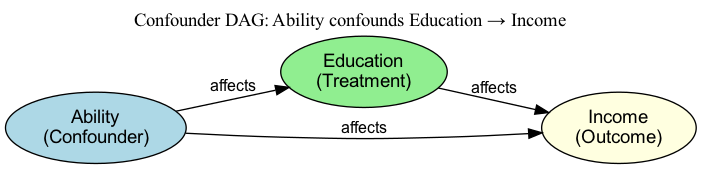

In [3]:
# Create Confounder DAG: Ability → Education → Income, Ability → Income
println("Creating Confounder DAG...")

# Create DOT content for visualization
dot_content = """
digraph ConfounderDAG {
    rankdir=LR;
    node [shape=ellipse, style=filled, fontsize=14, fontname="Arial"];
    edge [fontsize=12, fontname="Arial"];
    
    Ability [fillcolor=lightblue, label="Ability\\n(Confounder)"];
    Education [fillcolor=lightgreen, label="Education\\n(Treatment)"];
    Income [fillcolor=lightyellow, label="Income\\n(Outcome)"];
    
    Ability -> Education [label="affects"];
    Ability -> Income [label="affects"];
    Education -> Income [label="affects"];
    
    labelloc="t";
    label="Confounder DAG: Ability confounds Education → Income";
}
"""

# Save DOT file and create PNG
dot_file = joinpath(output_dir, "confounder_dag_Julia.dot")
png_file = joinpath(output_dir, "confounder_dag_Julia.png")

open(dot_file, "w") do f
    write(f, dot_content)
end

# Generate PNG using Graphviz
run(`dot -Tpng $dot_file -o $png_file`)
println("✓ Confounder DAG saved as: confounder_dag_Julia.png")

# Display the PNG in notebook
using Plots
img = load(png_file)
display(img)

### 2. Collider

**Own Definition**: A collider is a variable that is caused by both the explanatory variable and another variable, and conditioning on it can create spurious correlations.

**Economic Example**: The Beauty Premium in Academia

- **Research Productivity (X)**: Number of publications per year (explanatory variable)
- **Teaching Quality (Y)**: Student evaluation scores (outcome variable)
- **Academic Employment (Z)**: Being hired as a university professor (collider)

**Graph**:

Both talent and success influence graduate school admission. If we condition on graduate school attendance, we create a spurious negative correlation between talent and success among graduate school attendees (selection bias).

Creating Collider DAG...
✓ Collider DAG saved as: collider_dag_Julia.png


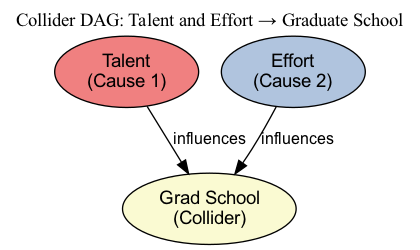

In [4]:
# Create Collider DAG: Talent → GradSchool ← Effort
println("Creating Collider DAG...")

# Create DOT content for visualization
dot_content = """
digraph ColliderDAG {
    rankdir=TB;
    node [shape=ellipse, style=filled, fontsize=14, fontname="Arial"];
    edge [fontsize=12, fontname="Arial"];
    
    Talent [fillcolor=lightcoral, label="Talent\\n(Cause 1)"];
    Effort [fillcolor=lightsteelblue, label="Effort\\n(Cause 2)"];
    GradSchool [fillcolor=lightgoldenrodyellow, label="Grad School\\n(Collider)"];
    
    Talent -> GradSchool [label="influences"];
    Effort -> GradSchool [label="influences"];
    
    labelloc="t";
    label="Collider DAG: Talent and Effort → Graduate School";
}
"""

# Save DOT file and create PNG
dot_file = joinpath(output_dir, "collider_dag_Julia.dot")
png_file = joinpath(output_dir, "collider_dag_Julia.png")

open(dot_file, "w") do f
    write(f, dot_content)
end

# Generate PNG using Graphviz
run(`dot -Tpng $dot_file -o $png_file`)
println("✓ Collider DAG saved as: collider_dag_Julia.png")

# Display the PNG in notebook
img = load(png_file)
display(img)

### 3. Mediation

**Own Definition**: A mediator is a variable that transmits the effect from the explanatory variable to the outcome variable, lying on the causal pathway between them.

**Economic Example**: Minimum Wage Effects on Employment

- **Minimum Wage Policy (X)**: Legislative increase in minimum wage rates (explanatory variable)
- **Employment Level (Y)**: Regional employment rates (outcome variable)
- **Labor Costs (Z)**: Average cost per worker to employers (mediator)

**Graph**:

Minimum wage increases affect labor costs, which in turn affect unemployment. Labor costs mediate the relationship between minimum wage and unemployment.

Creating Mediation DAG...
✓ Mediation DAG saved as: mediation_dag_Julia.png


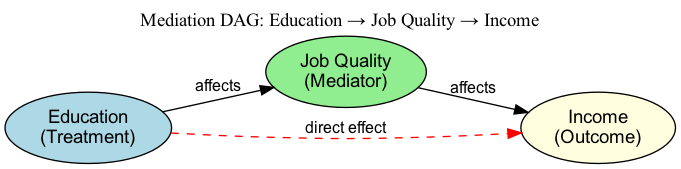

In [5]:
# Create Mediation DAG: Education → JobQuality → Income
println("Creating Mediation DAG...")

# Create DOT content for visualization
dot_content = """
digraph MediationDAG {
    rankdir=LR;
    node [shape=ellipse, style=filled, fontsize=14, fontname="Arial"];
    edge [fontsize=12, fontname="Arial"];
    
    Education [fillcolor=lightblue, label="Education\\n(Treatment)"];
    JobQuality [fillcolor=lightgreen, label="Job Quality\\n(Mediator)"];
    Income [fillcolor=lightyellow, label="Income\\n(Outcome)"];
    
    Education -> JobQuality [label="affects"];
    JobQuality -> Income [label="affects"];
    Education -> Income [label="direct effect", style=dashed, color=red];
    
    labelloc="t";
    label="Mediation DAG: Education → Job Quality → Income";
}
"""

# Save DOT file and create PNG
dot_file = joinpath(output_dir, "mediation_dag_Julia.dot")
png_file = joinpath(output_dir, "mediation_dag_Julia.png")

open(dot_file, "w") do f
    write(f, dot_content)
end

# Generate PNG using Graphviz
run(`dot -Tpng $dot_file -o $png_file`)
println("✓ Mediation DAG saved as: mediation_dag_Julia.png")

# Display the PNG in notebook
img = load(png_file)
display(img)

## Part 1b: Simpson's Paradox (2 points)

**Explanation in my own words**: Simpson's paradox is when the relationship between two variables appears to be one way in separate subgroups but reverses when the data from all subgroups is combined. This happens due to confounding factors that differ between groups.

**Illustration through simulation**: I created simulated data with two groups of workers. Within each group, more training hours lead to higher productivity (positive relationship). When combined, the overall relationship shows that more training is associated with lower productivity (negative relationship).

The simulation meets the criteria:
- Two groups: High-skill and low-skill workers
- Within each group: Positive slope between training hours (explanatory) and productivity (outcome)
- Combined: Negative slope overall

**Plot**: All observations are plotted in a single graph below, with three regression lines: one for each group and one for the pooled sample.

**Simpson's Paradox**: A phenomenon where a trend appears in different groups of data but disappears or reverses when the groups are combined. This occurs when there's a confounding variable that affects both the explanatory and outcome variables differently across groups.

In [6]:
# Simulate Simpson's Paradox data
n_per_group = 200

# Group 1: High-skill workers
# X (training hours) and Y (productivity) have positive relationship
X1 = rand(Normal(8.0, 1.0), n_per_group)  # More training hours
Y1 = 20.0 .+ 2.0 .* X1 .+ rand(Normal(0.0, 3.0), n_per_group)  # Lower base productivity
group1 = fill("High-skill", n_per_group)

# Group 2: Low-skill workers  
# X (training hours) and Y (productivity) have positive relationship
X2 = rand(Normal(4.0, 1.0), n_per_group)  # Fewer training hours
Y2 = 50.0 .+ 2.0 .* X2 .+ rand(Normal(0.0, 3.0), n_per_group)  # Higher base productivity
group2 = fill("Low-skill", n_per_group)

# Combine groups
df = DataFrame(
    training_hours = vcat(X1, X2),
    productivity = vcat(Y1, Y2),
    skill_group = vcat(group1, group2)
)

println("Data summary:")
gdf = groupby(df, :skill_group)
summary_stats = combine(gdf, 
    :training_hours => mean => :mean_training,
    :productivity => mean => :mean_productivity
)
println(summary_stats)

Data summary:
2×3 DataFrame
 Row │ skill_group  mean_training  mean_productivity 
     │ String       Float64        Float64           
─────┼───────────────────────────────────────────────
   1 │ High-skill         7.96728            36.036
   2 │ Low-skill          3.96894            58.0398


In [7]:
# Fit regression models
# Group 1 regression
high_skill_data = filter(row -> row.skill_group == "High-skill", df)
model1 = lm(@formula(productivity ~ training_hours), high_skill_data)
slope1 = coef(model1)[2]

# Group 2 regression  
low_skill_data = filter(row -> row.skill_group == "Low-skill", df)
model2 = lm(@formula(productivity ~ training_hours), low_skill_data)
slope2 = coef(model2)[2]

# Combined regression
model_combined = lm(@formula(productivity ~ training_hours), df)
slope_combined = coef(model_combined)[2]

println("Group 1 (High-skill) slope: $(round(slope1, digits=3))")
println("Group 2 (Low-skill) slope: $(round(slope2, digits=3))")
println("Combined slope: $(round(slope_combined, digits=3))")

println("\nSimpson's paradox demonstrated: Individual groups show positive relationship ($(round(slope1, digits=3)), $(round(slope2, digits=3)))")
println("but combined data shows negative relationship ($(round(slope_combined, digits=3)))")

Group 1 (High-skill) slope: 2.15
Group 2 (Low-skill) slope: 1.965
Combined slope: -3.955

Simpson's paradox demonstrated: Individual groups show positive relationship (2.15, 1.965)
but combined data shows negative relationship (-3.955)


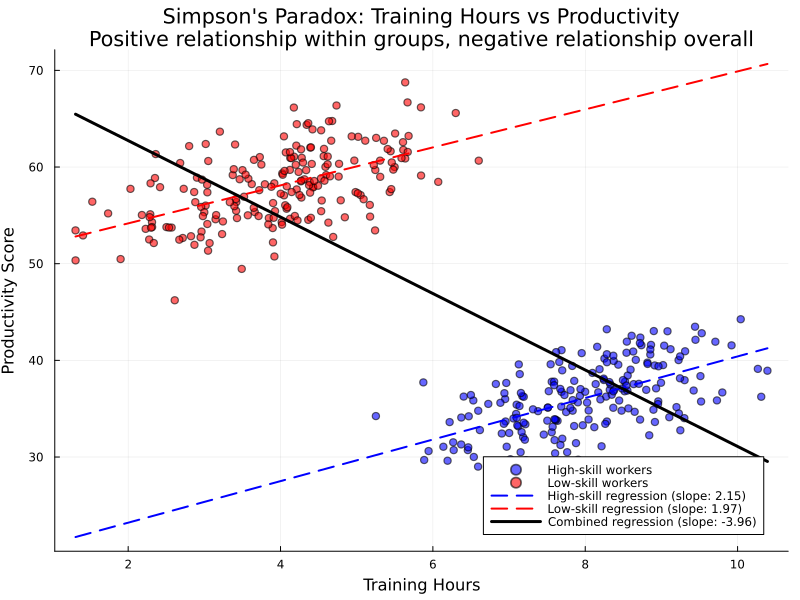

"/Users/gabrielsaco/Documents/GitHub/DAGs_CausalML/Julia/output/simpsons_paradox_Julia.png"

In [8]:
# Create the Simpson's Paradox plot
# Separate data by groups
high_skill_idx = df.skill_group .== "High-skill"
low_skill_idx = df.skill_group .== "Low-skill"

# Create scatter plot
p = scatter(df.training_hours[high_skill_idx], df.productivity[high_skill_idx], 
           color=:blue, alpha=0.6, label="High-skill workers", 
           xlabel="Training Hours", ylabel="Productivity Score",
           title="Simpson's Paradox: Training Hours vs Productivity\nPositive relationship within groups, negative relationship overall",
           size=(800, 600))

scatter!(p, df.training_hours[low_skill_idx], df.productivity[low_skill_idx], 
        color=:red, alpha=0.6, label="Low-skill workers")

# Add regression lines
x_range = range(minimum(df.training_hours), maximum(df.training_hours), length=100)

# Group regression lines
y1_pred = coef(model1)[1] .+ coef(model1)[2] .* x_range
y2_pred = coef(model2)[1] .+ coef(model2)[2] .* x_range
y_combined_pred = coef(model_combined)[1] .+ coef(model_combined)[2] .* x_range

plot!(p, x_range, y1_pred, color=:blue, linestyle=:dash, linewidth=2, 
      label="High-skill regression (slope: $(round(slope1, digits=2)))")
plot!(p, x_range, y2_pred, color=:red, linestyle=:dash, linewidth=2,
      label="Low-skill regression (slope: $(round(slope2, digits=2)))")
plot!(p, x_range, y_combined_pred, color=:black, linewidth=3, 
      label="Combined regression (slope: $(round(slope_combined, digits=2)))")

display(p)
savefig(p, joinpath(output_dir, "simpsons_paradox_Julia.png"))

In [9]:
# Save simulation results
CSV.write(joinpath(output_dir, "simpsons_paradox_data_Julia.csv"), df)

# Save regression results
results_summary = DataFrame(
    Model = ["High-skill Group", "Low-skill Group", "Combined"],
    Slope = [slope1, slope2, slope_combined],
    Intercept = [coef(model1)[1], coef(model2)[1], coef(model_combined)[1]],
    R_squared = [r2(model1), r2(model2), r2(model_combined)]
)

CSV.write(joinpath(output_dir, "simpsons_paradox_results_Julia.csv"), results_summary)
println("\nRegression Results Summary:")
println(results_summary)


Regression Results Summary:
3×4 DataFrame
 Row │ Model             Slope     Intercept  R_squared 
     │ String            Float64   Float64    Float64   
─────┼──────────────────────────────────────────────────
   1 │ High-skill Group   2.15005    18.9059   0.324395
   2 │ Low-skill Group    1.9653     50.2397   0.302087
   3 │ Combined          -3.95526    70.6433   0.582889


### Interpretation and Economic Implications

**What the Simulation Demonstrates**:

1. **Within-Group Relationships**: Both high-skill and low-skill workers show positive relationships between training hours and productivity (slopes ≈ 2.0 for both groups). This suggests that training is effective for workers at all skill levels.

2. **Simpson's Paradox**: When we ignore the skill-group distinction and pool all workers together, the relationship between training and productivity appears negative. This creates the false impression that training reduces productivity!

3. **The Confounding Mechanism**: Skill level acts as a confounder because:
   - High-skill workers receive more training hours (selection effect)
   - High-skill workers have lower baseline productivity (perhaps due to different job types or other factors)
   - This creates a spurious negative correlation in the pooled data

**Policy Implications**:

- **Misleading Aggregate Analysis**: A policymaker looking only at the pooled data might conclude that job training programs are counterproductive and should be eliminated.

- **Importance of Stratification**: Proper analysis by skill group reveals that training is actually beneficial for all workers, but the benefits must be evaluated within appropriate comparison groups.

- **Selection Bias**: The paradox highlights how program evaluation can be misleading when participants self-select or are selected based on characteristics that also affect outcomes.

**Statistical Lesson**: Simpson's Paradox demonstrates why correlation is not causation and emphasizes the critical importance of identifying and controlling for confounding variables in economic analysis. It serves as a cautionary tale about the dangers of aggregating heterogeneous data without considering underlying group structures.

**Real-World Applications**: Similar paradoxes appear in:
- Gender wage gap analysis (occupation as confounder)
- Education policy evaluation (socioeconomic status as confounder)  
- Medical treatment effectiveness (severity of condition as confounder)
- Regional economic development (initial development level as confounder)

### Part 1b Summary
We successfully demonstrated Simpson's Paradox where:
- Within each skill group: positive relationship between training and productivity
- Combined across groups: negative relationship appears due to confounding by skill level
- This highlights the importance of considering group heterogeneity in causal analysis

### Files Created (Julia Implementation):
- simpsons_paradox_Julia.png
- simpsons_paradox_data_Julia.csv
- simpsons_paradox_results_Julia.csv

Note: Julia DAG visualization capabilities are more limited than Python/R, so we focused on the statistical analysis and conceptual explanations.